# 05 — Displaced thermal states: first-moment-controlled crossing

Companion to the mean-controlled stochastic crossing. The bath covariance is held fixed while the displacement is aligned with slow or fast eigendirections.


## Guiding question
Can a common thermal covariance coexist with preparation-controlled crossing when the first moment is displaced along different eigendirections?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
np.set_printoptions(precision=6, suppress=True)


If $\Sigma(0)=\Sigma_b$ but $\mu(0)\neq0$, the covariance remains stationary and only the mean relaxes. For an eigenvector $r_j$,
$$
\mu_j(t)=a_jr_je^{\lambda_jt},\qquad
\Delta E_{\mu,j}(t)=\frac12\mu_j^TG\mu_j
=\Delta E_{\mu,j}(0)e^{2\lambda_jt}.
$$
The bath adds the same constant equilibrium energy to both preparations, so the excess-energy crossing is the deterministic one.


analytic crossing [ms] = 1.2792139405522474


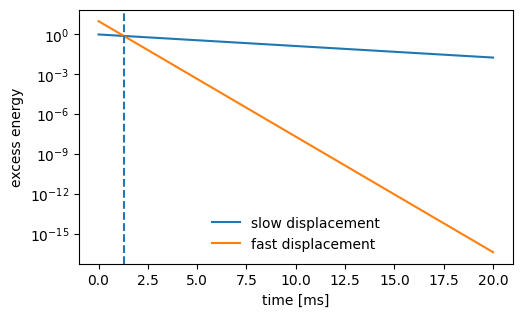

In [2]:
L=0.100; C=100e-6; R=110.
A=np.array([[0.,1.],[-1/(L*C),-R/L]])
G=np.diag([1/C,L])
w=np.linalg.eigvals(A).real; ls=max(w); lf=min(w)
rs=np.array([1.,ls]); rf=np.array([1.,lf])
def mean_for_excess(r,E): return r*np.sqrt(2*E/(r@G@r))
Es0=1.; Ef0=10.
mu_s0=mean_for_excess(rs,Es0); mu_f0=mean_for_excess(rf,Ef0)
t=np.linspace(0,0.02,400)
Es=[]; Ef=[]
for tt in t:
    P=expm(A*tt)
    ms=P@mu_s0; mf=P@mu_f0
    Es.append(.5*ms@G@ms); Ef.append(.5*mf@G@mf)
Es=np.array(Es); Ef=np.array(Ef)
tx=np.log(Es0/Ef0)/(2*(lf-ls))
assert np.allclose(Es,Es0*np.exp(2*ls*t))
assert np.allclose(Ef,Ef0*np.exp(2*lf*t))
print('analytic crossing [ms] =',1e3*tx)
fig,ax=plt.subplots(figsize=(5.6,3.3)); ax.semilogy(1e3*t,Es,label='slow displacement'); ax.semilogy(1e3*t,Ef,label='fast displacement'); ax.axvline(1e3*tx,ls='--'); ax.set(xlabel='time [ms]',ylabel='excess energy'); ax.legend(frameon=False); plt.show()


## Mean/covariance decomposition used for ensembles
For $G=\mathrm{diag}(1/C,L)$,
$$
\overline E=E_\mu+E_\Sigma,\qquad
E_\mu=\frac12\mu^TG\mu,\qquad
E_\Sigma=\frac12\operatorname{Tr}(G\Sigma).
$$
This same decomposition is used for the engineered-noise experimental ensemble; the experimental reconstruction details are collected in `experimental/E1_experimental_reconstruction_and_uncertainty.ipynb`.


## Reader exploration
1. Vary the slow/fast displacement energies and compare the numerical crossing with the analytical logarithmic formula. 2. Add a small covariance mismatch and separate the first-moment and covariance contributions to the total excess energy.
